In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    "engine_size_l": rng.uniform(1.0, 4.0, n),
    "horsepower": rng.integers(70, 320, n),
    "weight_kg": rng.integers(850, 2200, n),
    "cylinders": rng.choice([3, 4, 5, 6, 8], n)
})
df["mileage_kmpl"] = (
    30 - 2.2*df["engine_size_l"] - 0.018*df["horsepower"]
    - 0.0045*df["weight_kg"] - 0.7*df["cylinders"]
    + rng.normal(0, 1.5, n)
)
df.head()


,engine_size_l,horsepower,weight_kg,cylinders,mileage_kmpl
0,3.321868,272,1565,8,1.175828
1,2.316635,254,1201,3,10.759888
2,3.575794,209,1159,4,7.639826
3,3.092104,291,1285,5,5.302195
4,1.282532,102,1656,6,11.897391


In [3]:
print(df.describe())
print('Missing values:\n', df.isna().sum())


       engine_size_l  horsepower    weight_kg  cylinders  mileage_kmpl
count     500.000000  500.000000   500.000000  500.00000    500.000000
mean        2.487044  196.536000  1504.684000    5.14600     10.513658
std         0.860318   72.481362   395.399425    1.69305      3.602883
min         1.016290   70.000000   852.000000    3.00000      0.003788
25%         1.707945  138.000000  1160.500000    4.00000      8.144350
50%         2.502679  195.000000  1493.000000    5.00000     10.429848
75%         3.241733  260.000000  1851.250000    6.00000     12.876390
max         3.997314  319.000000  2193.000000    8.00000     19.740705
Missing values:
 engine_size_l    0
horsepower       0
weight_kg        0
cylinders        0
mileage_kmpl     0
dtype: int64


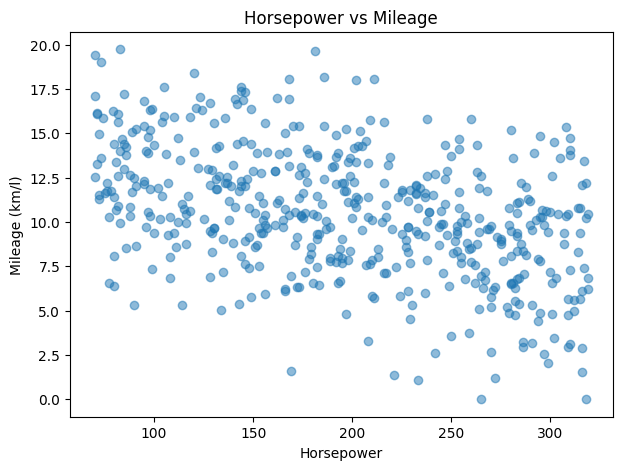

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(df["horsepower"], df["mileage_kmpl"], alpha=0.5)
plt.xlabel("Horsepower")
plt.ylabel("Mileage (km/l)")
plt.title("Horsepower vs Mileage")
plt.show()


In [5]:
X = df[["engine_size_l", "horsepower", "weight_kg", "cylinders"]]
y = df["mileage_kmpl"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,MAE,RMSE,R2
0,Linear Regression,1.448023,1.767568,0.815923
1,Random Forest Regression,1.770180,2.140552,0.730040


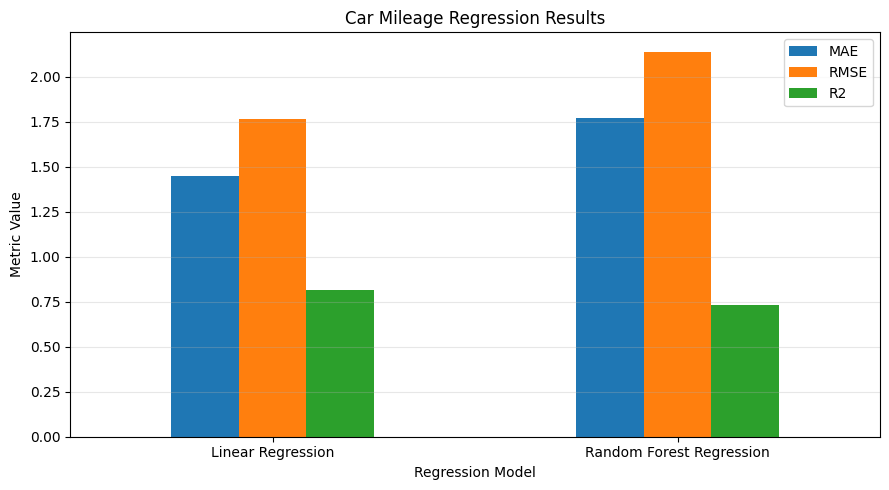

In [6]:
# Graph 1: Model performance comparison
metrics = results_df.set_index("Model")[["MAE", "RMSE", "R2"]]
ax = metrics.plot(kind="bar", figsize=(9,5), title="Car Mileage Regression Results")
ax.set_ylabel("Metric Value")
ax.set_xlabel("Regression Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

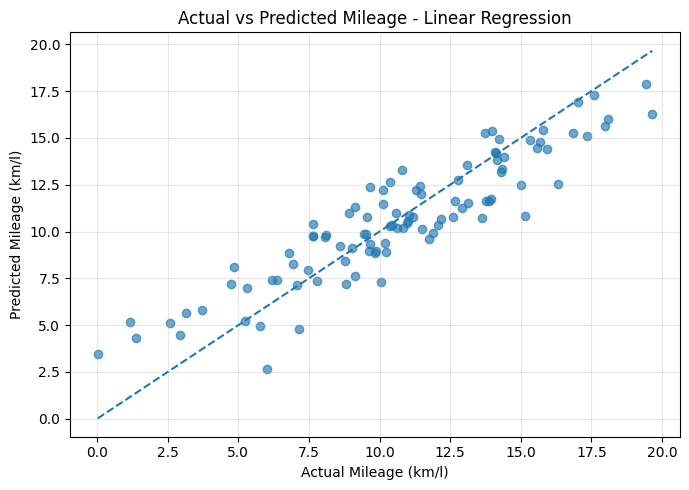

In [7]:
# Graph 2: Actual vs predicted mileage for the best R² model
best_name = results_df.loc[results_df["R2"].idxmax(), "Model"]
best_model_for_plot = models[best_name]
y_best_pred = best_model_for_plot.predict(X_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_best_pred, alpha=0.65)
line_min = min(y_test.min(), y_best_pred.min())
line_max = max(y_test.max(), y_best_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Actual Mileage (km/l)")
plt.ylabel("Predicted Mileage (km/l)")
plt.title(f"Actual vs Predicted Mileage - {best_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
best_model = models[results_df.loc[results_df["R2"].idxmax(), "Model"]]
new_car = pd.DataFrame({
    "engine_size_l": [1.6],
    "horsepower": [110],
    "weight_kg": [1150],
    "cylinders": [4]
})
print("Predicted mileage (km/l):", round(best_model.predict(new_car)[0], 2))


Predicted mileage (km/l): 16.2
